In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_missing_value_imputation.csv')

In [4]:
df

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,supertech araville,sector 79,0.71,5521.0,2,2,0,9.0,Under Construction,1295.0,0,0,0,0,0,0,0
1,flat,supertech araville,sector 79,0.95,6209.0,2,2,3,7.0,New Property,1385.0,1,0,0,0,0,0,49
2,flat,ireo skyon,sector 60,2.65,13125.0,3,4,3+,7.0,Moderately Old,2037.0,0,1,0,0,0,1,152
3,flat,bhemerlei,sohna road,0.69,5100.0,2,2,2,3.0,Under Construction,1350.0,0,0,0,0,0,0,0
4,flat,tata gurgaon gateway,sector 113,2.45,10788.0,3,3,3,8.0,Relatively New,2014.0,0,0,0,0,0,0,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,flat,godrej aria,sector 79,0.95,6552.0,2,2,3,5.0,Relatively New,1611.0,0,0,0,0,0,1,174
3651,flat,m3m one key resiments,sector 67,0.80,13115.0,1,1,0,0.0,Relatively New,610.0,0,0,0,0,0,0,0
3652,house,independent,sector 50,10.56,32593.0,5,5,3,3.0,Moderately Old,3240.0,0,1,0,0,0,0,20
3653,flat,godrej oasis,sector 88a,1.38,6680.0,3,3,3+,7.0,Relatively New,2296.0,0,1,0,0,0,0,72


<Axes: ylabel='luxury_score'>

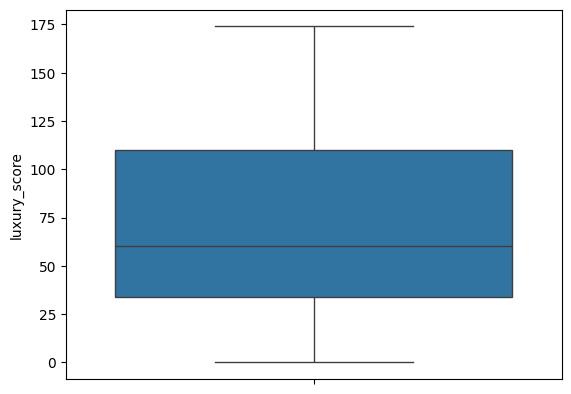

In [5]:
sns.boxplot(df['luxury_score'])

In [7]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [6]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None 

In [8]:

train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: ylabel='floorNum'>

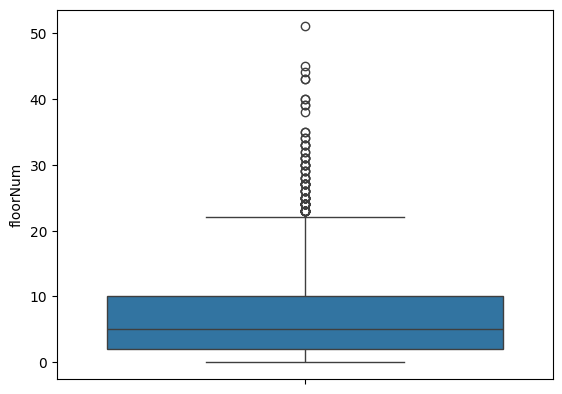

In [9]:
sns.boxplot(df['floorNum'])

In [10]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [11]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37c', 'sector 37d',
       'sector 38', 'sector 39', 'sector 4', 'sector 40', 'sector 41',
       'sector 43', 'sector 45', 'sector 46', 'sector 47', 'sector 48',
       'sector 49', 'sector 5', 'sector 50', 'sector 51', 'sector 52',
       'sector 53', 'sect

C:\Users\msi 1\AppData\Local\Temp\ipykernel_9204\848989002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


<Axes: >

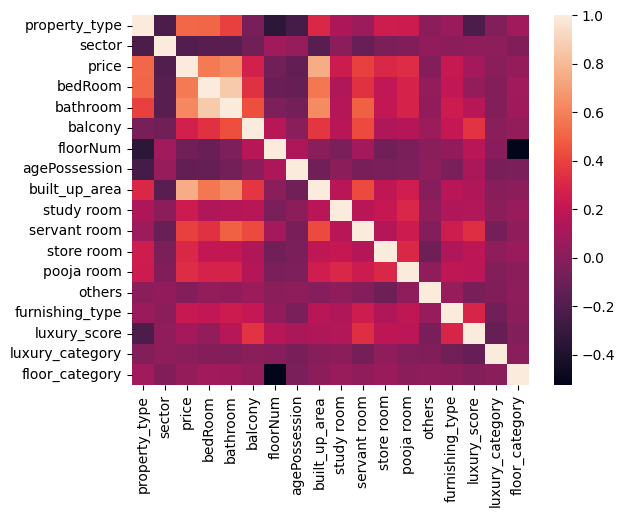

In [13]:
sns.heatmap(data_label_encoded.corr())

In [14]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.203058
1,price,1.000000
2,bedRoom,0.575787
3,bathroom,0.621891
4,balcony,0.270161
5,floorNum,-0.086024
6,agePossession,-0.136420
7,built_up_area,0.750482
8,study room,0.239859
9,servant room,0.390716


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.643020
0,property_type,0.101099
1,sector,0.096205
14,luxury_score,0.030622
3,bathroom,0.023930
2,bedRoom,0.018149
5,floorNum,0.017598
9,servant room,0.014544
6,agePossession,0.011607
4,balcony,0.008790


In [16]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.684899
0,property_type,0.103233
1,sector,0.099842
3,bathroom,0.035623
2,bedRoom,0.025893
9,servant room,0.018834
14,luxury_score,0.008355
5,floorNum,0.005870
10,store room,0.005486
8,study room,0.004476


In [17]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
7,built_up_area,0.724173
0,property_type,0.158034
1,sector,0.143166
14,luxury_score,0.017878
3,bathroom,0.016744
2,bedRoom,0.013765
9,servant room,0.012894
5,floorNum,0.008853
8,study room,0.004716
4,balcony,0.004171


In [18]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
7,built_up_area,1.484317
0,property_type,0.760302
3,bathroom,0.408491
10,store room,0.196474
8,study room,0.158630
13,furnishing_type,0.156348
9,servant room,0.119698
11,pooja room,0.081395
15,luxury_category,0.049075
5,floorNum,0.037013


In [19]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
7,built_up_area,0.642399
0,property_type,0.098271
1,sector,0.093570
14,luxury_score,0.030923
3,bathroom,0.023232
2,bedRoom,0.021443
5,floorNum,0.018112
9,servant room,0.016030
6,agePossession,0.011714
4,balcony,0.009242


In [21]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
7,built_up_area,1.491045
0,property_type,0.780714
3,bathroom,0.486702
10,store room,0.200912
13,furnishing_type,0.168014
8,study room,0.166364
9,servant room,0.119372
11,pooja room,0.089336
5,floorNum,0.068862
15,luxury_category,0.059394


In [22]:
!pip install shap

In [23]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-1.60540828e-01, -2.38432970e-01, -6.32861592e-02, ...,
        -6.80320937e-02,  3.93690327e-03,  2.24145425e-03],
       [-1.88050504e-01, -2.65959153e-01, -6.79509564e-02, ...,
        -1.49753003e-02,  5.52895178e-03,  4.22598851e-03],
       [-4.31373088e-01,  6.34514908e-01, -1.08175764e-02, ...,
         9.07814779e-03,  1.55180730e-03,  8.45312084e-03],
       ...,
       [ 1.58900716e+00,  9.70241309e-01,  2.25684647e-01, ...,
         1.17745755e-01, -2.12906300e-03, -1.54803475e-02],
       [-4.25130787e-01, -6.64248587e-01, -1.90080317e-02, ...,
        -3.79058406e-03, -1.62219163e-02,  2.97839629e-03],
       [-1.52686482e-01, -1.32350265e-01, -3.95660953e-02, ...,
        -4.55897624e-02,  2.00211414e-03,  4.06961501e-05]],
      shape=(3655, 17))

In [24]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,1.241659
0,property_type,0.469258
1,sector,0.367315
3,bathroom,0.110673
9,servant room,0.068729
14,luxury_score,0.057601
5,floorNum,0.053215
2,bedRoom,0.045920
4,balcony,0.030844
6,agePossession,0.023105


In [25]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [26]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.203058,0.096205,0.099842,0.143166,-0.062530,0.093570,-0.072080,0.367315
bedRoom,0.575787,0.018149,0.025893,0.013765,-0.135167,0.021443,-0.226243,0.045920
bathroom,0.621891,0.023930,0.035623,0.016744,0.408491,0.023232,0.486702,0.110673
balcony,0.270161,0.008790,0.000576,0.004171,-0.025335,0.009242,-0.047273,0.030844
floorNum,-0.086024,0.017598,0.005870,0.008853,0.037013,0.018112,0.068862,0.053215
agePossession,-0.136420,0.011607,0.003882,0.000731,-0.007434,0.011714,-0.016074,0.023105
built_up_area,0.750482,0.643020,0.684899,0.724173,1.484317,0.642399,1.491045,1.241659
study room,0.239859,0.007526,0.004476,0.004716,0.158630,0.005976,0.166364,0.016995
servant room,0.390716,0.014544,0.018834,0.012894,0.119698,0.016030,0.119372,0.068729


In [27]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.712174
sector             0.130271
bathroom           0.032626
luxury_score       0.024884
bedRoom            0.021918
servant room       0.020345
floorNum           0.016243
agePossession      0.008422
balcony            0.007987
study room         0.006637
store room         0.006445
furnishing_type    0.006378
pooja room         0.003160
others             0.001761
floor_category     0.001664
luxury_category   -0.000915
dtype: float64

In [28]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [29]:
scores.mean()

np.float64(0.8228911462354436)

In [30]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [31]:
scores.mean()

np.float64(0.8244557028246848)

In [32]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [33]:
export_df.to_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_feature_selection.csv', index=False)